## Summary:

This notebook evaluates the geometric and physical structure of the latent space by visualizing how the encoder maps Hamiltonian parameters to a compressed representation. It generates scatter plots to demonstrate how the model organizes data by physical properties.

## Requirements:

- You need to have generated or saved ham-terms and two-rdm instances 
- You need to have trained or saved models for system sizes ```L=[5,6,7]```




In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from dftqml.autoencoders.ae import load_model
import torch
import torch.nn.functional as F
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dftqml.autoencoders import autoencoder_utils

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

# Illustrating the Latent Space

(tensor(4.6242, grad_fn=<SumBackward0>), tensor(4.1756, grad_fn=<SumBackward0>))


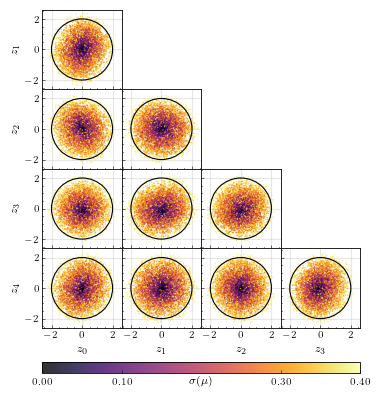

In [2]:
def correlation_plot(data, c=None, circle_radius=2):
    """
    Create a publication-ready correlation plot for a double-column paper.

    Parameters
    ----------
    data : array-like, shape (n_samples, n_features)
        The data to plot
    c : array-like, optional
        Color values for the scatter points
    circle_radius : float, default=2
        Radius of the circle indicating the distribution

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    """
    n_features = data.shape[1]

    # Calculate figure height to maintain square subplots
    # Account for spacing and colorbar
    subplot_size = 3.7 / (n_features - 1)  # Size per subplot in inches
    fig_height = subplot_size * (n_features - 1)

    # Add extra space for colorbar if needed
    if c is not None:
        fig_height += 0.35  # Extra space for colorbar

    fig, axes = plt.subplots(
        n_features - 1,
        n_features - 1,
        figsize=(3.5, fig_height),
        sharex="col",
        sharey="row",
        gridspec_kw={"hspace": 0.0, "wspace": 0.0},
    )

    # Ensure axes is 2D for consistent indexing
    if n_features == 2:
        axes = np.array([[axes]])
    else:
        axes = np.atleast_2d(axes)

    # Calculate data limits with small padding
    data_min, data_max = np.min(data), np.max(data)
    data_range = data_max - data_min
    padding = 0.05 * data_range
    lims = [data_min - padding, data_max + padding]

    # Store scatter plot for colorbar reference
    sc = None

    for i in range(n_features - 1):
        for j in range(n_features - 1):
            ax = axes[i, j]
            # ax.grid(True, linestyle='--', alpha=0.7)
            ax.grid(True, which="major", linestyle="-", alpha=0.3)

            # Hide upper triangle
            if j > i:
                ax.axis("off")
                continue

            # Create scatter plot
            sc = ax.scatter(
                data[:, j],
                data[:, i + 1],
                s=1,
                alpha=0.8,
                c=c,
                cmap="inferno" if c is not None else None,
                rasterized=True,
                linewidths=0,
                zorder=4,
            )

            # Add black circle with specified radius at origin
            circle = Circle(
                (0, 0),
                circle_radius,
                color="black",
                fill=False,
                linewidth=0.8,
                zorder=10,
            )
            ax.add_patch(circle)

            # Set axis limits to be equal (ensures square appearance)
            ax.set_xlim(*lims)
            ax.set_ylim(*lims)
            ax.set_aspect("equal", adjustable="box")

            # Configure tick parameters
            ax.tick_params(direction="in", length=2, pad=2, labelsize=7)

            # Only show tick labels on edges
            if j > 0:
                ax.tick_params(labelleft=False)
            if i < n_features - 2:
                ax.tick_params(labelbottom=False)

            # Set axis labels only on edges
            if j == 0:
                ax.set_ylabel(rf"$z_{{{i+1}}}$", fontsize=8)
            if i == n_features - 2:
                ax.set_xlabel(rf"$z_{{{j}}}$", fontsize=8)

            # Add minor ticks for professional appearance
            ax.minorticks_on()
            ax.tick_params(which="minor", length=1, direction="in")

            # Set symmetric ticks around zero
            ax.set_xticks([-2, 0, 2])
            ax.set_yticks([-2, 0, 2])

            ax.set_ylim(-2.6, 2.6)
            ax.set_xlim(-2.6, 2.6)

    # Adjust layout before adding colorbar
    fig.tight_layout(pad=0)

    if c is not None and sc is not None:
        # Create horizontal colorbar below the figure
        cbar = fig.colorbar(
            sc,
            ax=axes.ravel().tolist(),
            orientation="horizontal",
            fraction=0.08,
            pad=0.09,  # Reduced padding
            aspect=30,
            shrink=1.0,
        )

        # Configure colorbar appearance
        cbar.ax.tick_params(labelsize=7, width=0.4, length=2, direction="in")
        cbar.outline.set_linewidth(0.6)

        # Create ticks at edges and quarters, but skip the middle one
        tick_positions = np.linspace(np.min(c), np.max(c), 5)
        tick_labels = [f"{val:.2f}" for val in tick_positions]

        # Set ticks, excluding the middle position
        cbar.set_ticks(
            [tick_positions[0], tick_positions[1], tick_positions[3], tick_positions[4]]
        )
        cbar.set_ticklabels(
            [tick_labels[0], tick_labels[1], tick_labels[3], tick_labels[4]]
        )

        # Position label in the middle where tick is omitted
        cbar.set_label(r"$\sigma(\mu)$", fontsize=8, labelpad=-7.5)

        # Adjust label position to be at same level as tick labels
        label = cbar.ax.xaxis.label
        label.set_verticalalignment("top")
        label.set_horizontalalignment("center")

    return fig


input_type = "ham_terms"
latent_diff = -1
L = 6

checkpoint_kwargs = dict(
    models_dir="../models/bs256",
    input_type=input_type,
    L=L,
    N=L,
    U=4.0,
    interpolation="geometric",
    enable_batchnorm=False,
    hidden_depth=4,
    latent_dim=L + latent_diff,
    min_dim=L**2,
    scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
    weight_decay=None,
    lambda_latent_norm=1e-7,
    lambda_latent_repulsion=1e-7,
    lambda_lipschitz_encoder=1e-9,
    lambda_lipschitz_decoder=1e-8,
    iteration=1,
    linear_encoder=False,
    augment_by_symmetry=True
    )

checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)

model = load_model(checkpoint_dir, device="cpu")

n_test_data = 10000

data_path = f"../data/L{L}-N{L}-U4.0_reduced.hdf5"
with h5py.File(data_path, "r") as f:
    x = f["hamiltonian_terms"][-n_test_data + 1 :]
    potentials = f["potentials"][-n_test_data + 1 :]
    densities = f["densities"][-n_test_data + 1 :]

input_vector = torch.Tensor(x.reshape((9999, 3 * L)))
latent_vectors = model.encode(input_vector).detach().numpy()


fig = correlation_plot(latent_vectors, c=np.std(potentials, axis=1))
# fig.savefig('correlation_plot.pdf', dpi=300, bbox_inches='tight')

# Latent Space of Uneven Systems

In [ ]:
iter_dict = {}
for i in range(3):
    loss_dict = {}

    for L in [5, 7]:
        loss_dict[L] = []
        for z in [L - 3, L - 2, L - 1, L, L + 1, L + 2]:
            
            checkpoint_kwargs = dict(
                models_dir="../models/bs256",
                input_type=input_type,
                L=L,
                N=L-1 if L==5 else L+1,
                U=4.0,
                interpolation="geometric",
                enable_batchnorm=False,
                hidden_depth=4,
                latent_dim=z,
                min_dim=L**2,
                scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
                weight_decay=None,
                lambda_latent_norm=1e-7,
                lambda_latent_repulsion=1e-7,
                lambda_lipschitz_encoder=1e-9,
                lambda_lipschitz_decoder=1e-8,
                iteration=i,
                linear_encoder=False,
                augment_by_symmetry=True
                )

            checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)
            model = load_model(checkpoint_dir, device="cpu")

            n_test_data = 10000

            if L == 5:
                data_path = f"../data/L{L}-N{L-1}-U4.0_reduced.hdf5"
            if L == 7:
                data_path = f"../data/L{L}-N{L+1}-U4.0_reduced.hdf5"
            with h5py.File(data_path, "r") as f:
                x = f["hamiltonian_terms"][-n_test_data + 1 :]
                potentials = f["potentials"][-n_test_data + 1 :]
                densities = f["densities"][-n_test_data + 1 :]

            input_vector = torch.Tensor(x.reshape((9999, 3 * L)))
            recon_vector = model(input_vector)
            if L == 5 and z == L - 1 and i == 0:
                latent_vectors = model.encode(input_vector).detach().numpy()
                pot = potentials
            input_vector = torch.Tensor(x)

            loss_dict[L].append(
                np.sqrt(
                    F.mse_loss(input_vector, recon_vector, reduction="mean")
                    .detach()
                    .numpy()
                )
            )
    iter_dict[i] = loss_dict

(tensor(4.2629, grad_fn=<SumBackward0>), tensor(3.7906, grad_fn=<SumBackward0>))
(tensor(4.4011, grad_fn=<SumBackward0>), tensor(3.8745, grad_fn=<SumBackward0>))
(tensor(4.3899, grad_fn=<SumBackward0>), tensor(3.9056, grad_fn=<SumBackward0>))
(tensor(4.3475, grad_fn=<SumBackward0>), tensor(3.9315, grad_fn=<SumBackward0>))
(tensor(4.3507, grad_fn=<SumBackward0>), tensor(3.9662, grad_fn=<SumBackward0>))
(tensor(4.3855, grad_fn=<SumBackward0>), tensor(4.0774, grad_fn=<SumBackward0>))
(tensor(4.8163, grad_fn=<SumBackward0>), tensor(4.2685, grad_fn=<SumBackward0>))
(tensor(4.8052, grad_fn=<SumBackward0>), tensor(4.3255, grad_fn=<SumBackward0>))
(tensor(4.8389, grad_fn=<SumBackward0>), tensor(4.3541, grad_fn=<SumBackward0>))
(tensor(4.8090, grad_fn=<SumBackward0>), tensor(4.4638, grad_fn=<SumBackward0>))
(tensor(4.8362, grad_fn=<SumBackward0>), tensor(4.4415, grad_fn=<SumBackward0>))
(tensor(4.7995, grad_fn=<SumBackward0>), tensor(4.4745, grad_fn=<SumBackward0>))
(tensor(4.3354, grad_fn=<Sum

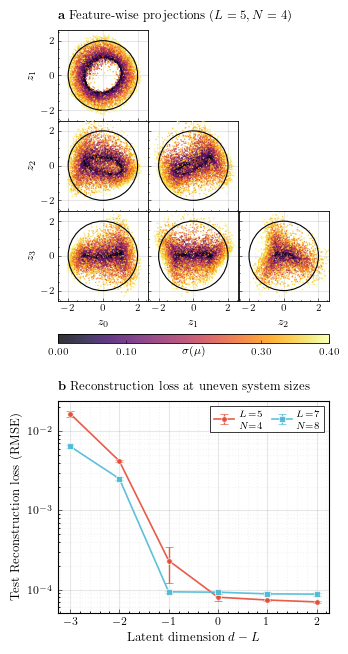

In [6]:
def merged_latent_analysis_plot(latent_vectors, potentials, iter_dict, circle_radius=2):
    """
    Create a 2-panel figure with correlation plot (top) and reconstruction loss (bottom).

    Parameters
    ----------
    latent_vectors : array-like, shape (n_samples, n_features)
        Latent space data for correlation plot
    potentials : array-like
        Potential values for coloring correlation plot
    loss_dict : dict
        Dictionary with keys as system sizes L and values as lists of losses
    circle_radius : float, default=2
        Radius of circle in correlation plot

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    """
    n_features = latent_vectors.shape[1]

    # Calculate subplot sizes
    subplot_size = 3.7 / (n_features - 1)
    corr_height = subplot_size * (n_features - 1) + 0.2  # Include colorbar space
    loss_height = 2.5
    total_height = corr_height + loss_height

    # Create figure with GridSpec
    fig = plt.figure(figsize=(3.5, total_height))
    gs = GridSpec(
        2,
        1,
        height_ratios=[corr_height, loss_height],
        hspace=0.15,
        top=0.96,
        bottom=0.05,
    )

    # ==================== Panel A: Correlation Plot ====================
    gs_corr = gs[0].subgridspec(n_features - 1, n_features - 1, hspace=0.0, wspace=0.0)

    axes_corr = np.array(
        [
            [fig.add_subplot(gs_corr[i, j]) for j in range(n_features - 1)]
            for i in range(n_features - 1)
        ]
    )

    if n_features == 2:
        axes_corr = np.array([[axes_corr]])
    else:
        axes_corr = np.atleast_2d(axes_corr)

    # Calculate data limits
    data_min, data_max = np.min(latent_vectors), np.max(latent_vectors)
    data_range = data_max - data_min
    padding = 0.05 * data_range
    lims = [data_min - padding, data_max + padding]

    c = np.std(potentials, axis=1)
    sc = None

    for i in range(n_features - 1):
        for j in range(n_features - 1):
            ax = axes_corr[i, j]
            ax.grid(True, which="major", linestyle="-", alpha=0.3)

            if j > i:
                ax.axis("off")
                continue

            sc = ax.scatter(
                latent_vectors[:, j],
                latent_vectors[:, i + 1],
                s=1,
                alpha=0.8,
                c=c,
                cmap="inferno",
                rasterized=True,
                linewidths=0,
                zorder=4,
            )

            circle = Circle(
                (0, 0),
                circle_radius,
                color="black",
                fill=False,
                linewidth=0.8,
                zorder=10,
            )
            ax.add_patch(circle)

            ax.set_xlim(*lims)
            ax.set_ylim(*lims)
            ax.set_aspect("equal", adjustable="box")

            ax.tick_params(direction="in", length=2, pad=2, labelsize=7)

            if j > 0:
                ax.tick_params(labelleft=False)
            if i < n_features - 2:
                ax.tick_params(labelbottom=False)

            if j == 0:
                ax.set_ylabel(rf"$z_{{{i+1}}}$", fontsize=8)
            if i == n_features - 2:
                ax.set_xlabel(rf"$z_{{{j}}}$", fontsize=8)

            ax.minorticks_on()
            ax.tick_params(which="minor", length=1, direction="in")

            ax.set_xticks([-2, 0, 2])
            ax.set_yticks([-2, 0, 2])
            ax.set_ylim(-2.6, 2.6)
            ax.set_xlim(-2.6, 2.6)

    # Add colorbar for correlation plot
    if sc is not None:
        cbar = fig.colorbar(
            sc,
            ax=axes_corr.ravel().tolist(),
            orientation="horizontal",
            fraction=0.08,
            pad=0.1,
            aspect=30,
            shrink=1.0,
        )

        cbar.ax.tick_params(labelsize=7, width=0.4, length=2, direction="in")
        cbar.outline.set_linewidth(0.6)

        tick_positions = np.linspace(np.min(c), np.max(c), 5)
        tick_labels = [f"{val:.2f}" for val in tick_positions]

        cbar.set_ticks(
            [tick_positions[0], tick_positions[1], tick_positions[3], tick_positions[4]]
        )
        cbar.set_ticklabels(
            [tick_labels[0], tick_labels[1], tick_labels[3], tick_labels[4]]
        )

        cbar.set_label(r"$\sigma(\mathbf{\mu})$", fontsize=8, labelpad=-7.5)

        label = cbar.ax.xaxis.label
        label.set_verticalalignment("top")
        label.set_horizontalalignment("center")

    # Add panel title
    # fig.text(0.02, 0.96, r'\textbf{a} Feature-wise projections $(L=5, N=4)$', fontsize=9, va='top', ha='left')
    axes_corr[0, 0].set_title(
        r"\textbf{a} Feature-wise projections $(L=5, N=4)$",
        fontsize=9,
        loc="left",
        pad=8,
    )

    # ==================== Panel B: Reconstruction Loss ====================
    ax_loss = fig.add_subplot(gs[1])

    colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
    markers = ["o", "s", "^", "D", "v", "p"]

    L_values = sorted(loss_dict.keys())

    for idx, L in enumerate(L_values):
        if L == 5:
            N = 4
        if L == 7:
            N = 8
        losses = np.array([iter_dict[i][L] for i in range(3)])  # shape: (n_iter, 6)

        mean_losses = losses.mean(axis=0)  # shape: (6,)
        std_losses = losses.std(axis=0)

        z_minus_L = [-3, -2, -1, 0, 1, 2]

        ax_loss.errorbar(
            z_minus_L,
            mean_losses,
            yerr=std_losses,
            marker=markers[idx],
            markersize=4,
            linewidth=1.2,
            color=colors[idx],
            label=rf"$\begin{{array}}{{l@{{}}c@{{}}l}}L&=&{L}\\N&=&{N}\end{{array}}$",
            markerfacecolor=colors[idx],
            markeredgewidth=0.5,
            markeredgecolor="white",
            capsize=3,
            capthick=1,
            elinewidth=1,
            alpha=0.9,
        )

    ax_loss.set_yscale("log")
    ax_loss.grid(True, which="major", linestyle="-", alpha=0.3)
    ax_loss.grid(True, which="minor", linestyle=":", alpha=0.15)

    ax_loss.set_xlabel(r"Latent dimension $d - L$", fontsize=9)
    ax_loss.set_ylabel(r"Test Reconstruction loss (RMSE)", fontsize=9)
    ax_loss.set_xticks([-3, -2, -1, 0, 1, 2])

    legend = ax_loss.legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=2,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
    legend.get_frame().set_linewidth(0.6)

    ax_loss.tick_params(direction="in", which="both", labelsize=8)
    ax_loss.tick_params(which="major", length=3)
    ax_loss.tick_params(which="minor", length=1.5)
    ax_loss.minorticks_on()

    for spine in ax_loss.spines.values():
        spine.set_linewidth(0.8)

    # Add panel title
    ax_loss.set_title(
        r"\textbf{b} Reconstruction loss at uneven system sizes",
        fontsize=9,
        loc="left",
        pad=8,
    )

    return fig


fig = merged_latent_analysis_plot(latent_vectors, pot, iter_dict)
# fig.savefig("uneven_performance.pdf", dpi=300, bbox_inches="tight")